C:\Users\samho\AppData\Local\Temp\ipykernel_22184\2288291240.py:19: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.15)


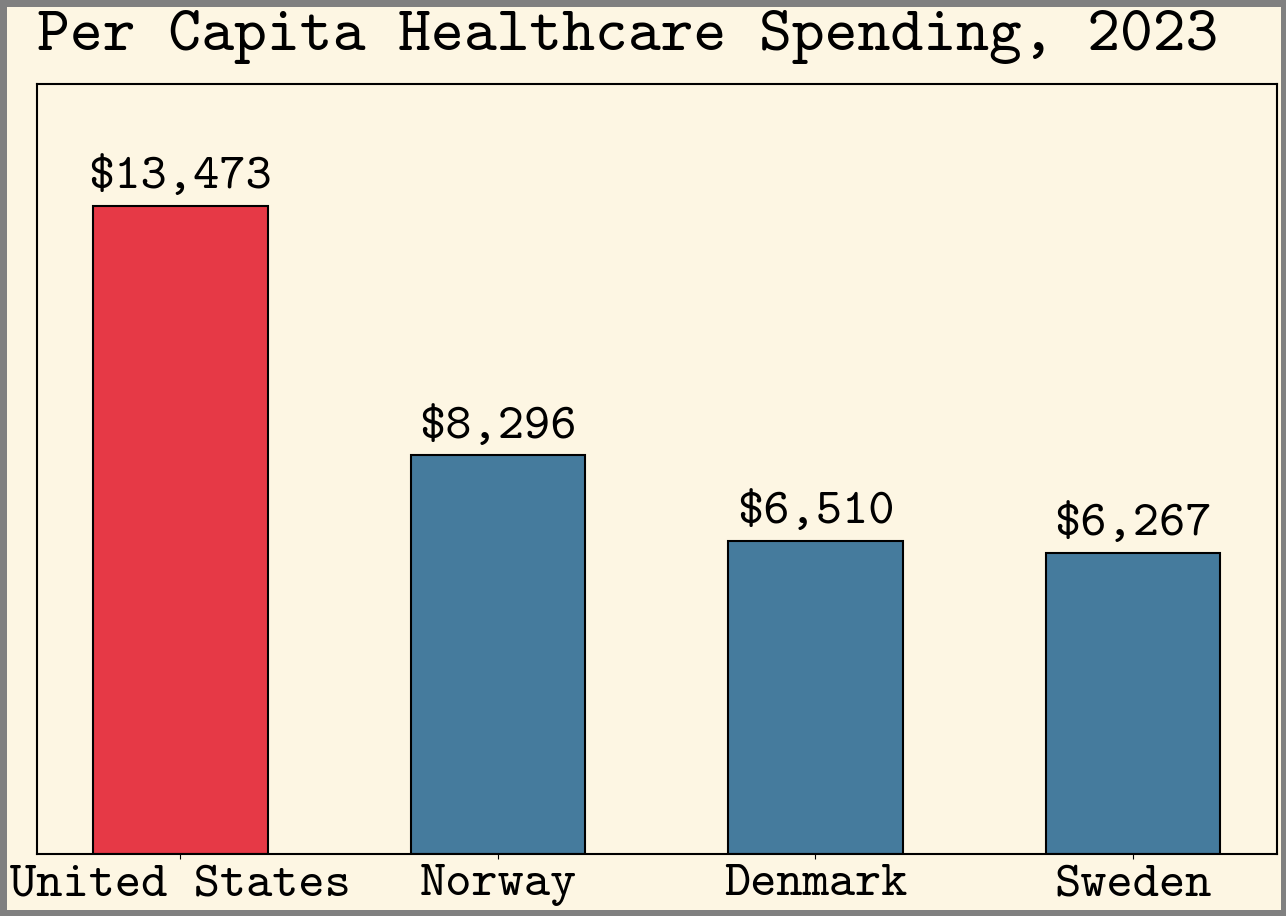

In [1]:
import matplotlib.pyplot as plt

# Apply the Beyond the Tribe custom style
plt.style.use('btt_style')

# Data
countries = ['United States', 'Norway', 'Denmark', 'Sweden']
spending = [13473, 8296, 6510, 6267]

# THE FIX: Disable the auto-layout engine so we can control the margins
fig, ax = plt.subplots()
fig.set_layout_engine('none')

# Thicken the outer border so it actually shows up
fig.patch.set_linewidth(8)
fig.patch.set_edgecolor('gray')

# Hardcode perfectly symmetrical margins (adjust these fractions if needed)
fig.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.15)

# Colors: Bold highlight for US, muted for Nordics
colors = ['#E63946', '#457B9D', '#457B9D', '#457B9D']

bars = ax.bar(countries, spending, color=colors, width=0.55)

# Title and Subtitle text
ax.set_title('Per Capita Healthcare Spending, 2023', 
             loc='left', pad=25)

# Remove Y-axis ticks and labels to rely on direct data labels
ax.tick_params(axis='y', left=False, labelleft=False)

# Add headroom for the size 36 font so it doesn't clip
ax.set_ylim(0, 16000) 

# Add direct data labels to bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'${height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  
                textcoords="offset points",
                ha='center', va='bottom',
                fontweight='bold',
                fontsize=36)

# Force the savefig command to respect your background and border colors
plt.savefig('healthcare_comparison.png', dpi=300, facecolor=fig.get_facecolor(), edgecolor=fig.get_edgecolor())